<a href="https://colab.research.google.com/github/Anusha-Vani/Retail-sales-eda-analysis/blob/main/Retail_sales_eda_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Import libraries

In [2]:
import pandas as pd
import numpy as np

#Import dataset

In [3]:
df=pd.read_csv("/content/retail_sales_dataset.csv")
df

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
...,...,...,...,...,...,...,...,...,...
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150


##Data exploration

In [4]:
df.shape

(1000, 9)

In [5]:
df.dtypes

,0
Transaction ID,int64
Date,object
Customer ID,object
Gender,object
Age,int64
Product Category,object
Quantity,int64
Price per Unit,int64
Total Amount,int64


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [7]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


##Data cleaning

###Null values

In [8]:
df.isnull().sum()

,0
Transaction ID,0
Date,0
Customer ID,0
Gender,0
Age,0
Product Category,0
Quantity,0
Price per Unit,0
Total Amount,0


##Duplicate values

In [9]:
df.duplicated().sum()

np.int64(0)

##Data analysis

In [23]:
a=df.groupby("Product Category")["Quantity"].max()
a=pd.DataFrame(a)
a

,Quantity
Product Category,
Beauty,4
Clothing,4
Electronics,4


###Beauty,Clothing,Electronics are the maximum selling products

In [15]:
b=df.groupby("Gender")["Total Amount"].mean()
b=pd.DataFrame(b)
b

,Total Amount
Gender,
Female,456.549020
Male,455.428571


###Female are generating the more revenue

In [17]:
c=pd.DataFrame(df.groupby("Product Category")["Age"].mean())
c

,Age
Product Category,
Beauty,40.371336
Clothing,41.948718
Electronics,41.736842


The target customers are around 40 years of age

In [19]:
a=df["Total Amount"].sum()
a

np.int64(456000)

In [21]:
b=df["Customer ID"].count()
b

np.int64(1000)

In [22]:
a/b

np.float64(456.0)

In [25]:
d=pd.DataFrame(df.groupby("Product Category")["Total Amount"].mean().sort_values(ascending=False))
d


,Total Amount
Product Category,
Beauty,467.475570
Electronics,458.786550
Clothing,443.247863


###Beauty is generating the highest revenue

In [27]:
e=pd.DataFrame(df.groupby("Product Category")["Price per Unit"].count().sort_values(ascending=False))
e


,Price per Unit
Product Category,
Clothing,351
Electronics,342
Beauty,307


###Clothing is the maximum selling product

In [29]:
f=df.groupby("Product Category")["Price per Unit"].sum().sort_values(ascending=False)
f


,Price per Unit
Product Category,
Electronics,62210
Clothing,61175
Beauty,56505


##Data visualization

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

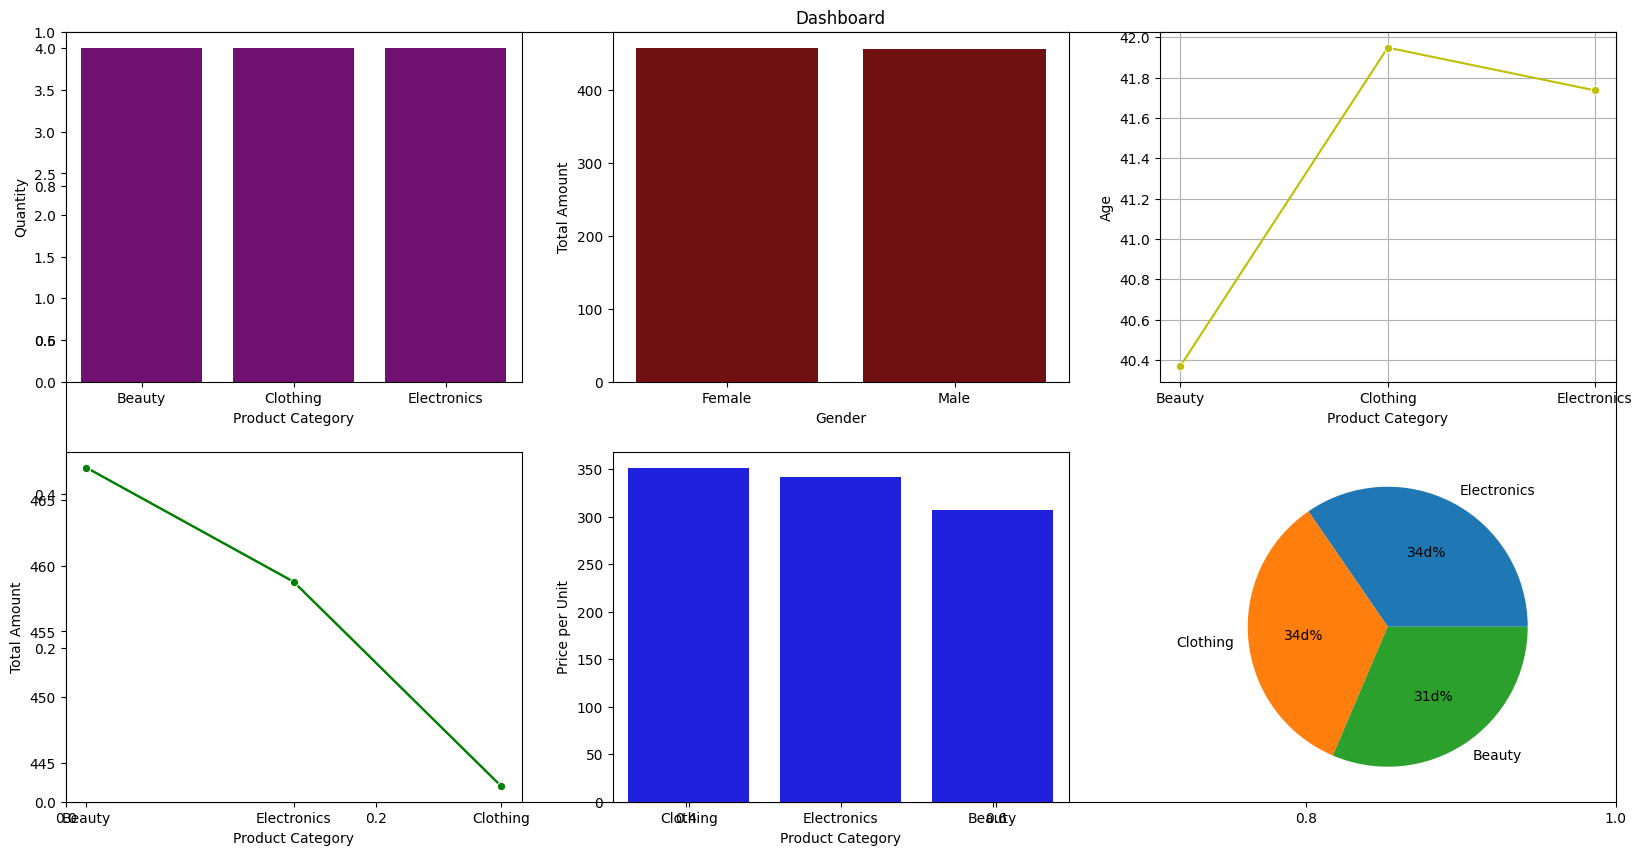

In [32]:
plt.figure(figsize=(20,10))
plt.title("Dashboard")
plt.subplot(2,3,1)
a=df.groupby("Product Category")["Quantity"].max()
a=pd.DataFrame(a)
sns.barplot(x="Product Category",y="Quantity",color="purple",data=a)
plt.subplot(2,3,2)
b=pd.DataFrame(df.groupby("Gender")["Total Amount"].mean())
sns.barplot(x="Gender",y="Total Amount",color="maroon",data=b)
plt.subplot(2,3,3)
sns.lineplot(x="Product Category",y="Age",color="y",marker="o",data=c)
plt.grid(True)
plt.subplot(2,3,4)
sns.lineplot(x="Product Category",y="Total Amount",color="green",marker="o",data=d)
plt.subplot(2,3,4)
sns.lineplot(x="Product Category",y="Total Amount",color="green",marker="o",data=d)
plt.subplot(2,3,5)
sns.barplot(x="Product Category",y="Price per Unit",color="blue",data=e)
plt.subplot(2,3,6)
plt.pie(f.values,labels=f.index,autopct="%id%%")
plt.show()

##Data story telling

### Beauty, electronics and Clothing are the maximum selling product
### Average Revenue is around 450 $
### Target Customers is around 40 years of age
### Beauty product is generating highest revenue
### Clothing is the maximum selling product
### Electronics product has maximum total price